## Churn Analysis and Customer Intelligence

In [1]:
# Churn Analysis and Customer Intelligence

In [2]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector as msq

## 1. Import data from mysql Database

In [3]:
# MySQL connection
conn = msq.connect(
    host="localhost",
    user="root",
    port=3308,
    password="Kunal@2909",
    database="customer"
)

print("Database Loaded Successfully...")

Database Loaded Successfully...


In [4]:
cus_sql = "select * from customer"
sub_sql = "select * from subscription"
support_sql = "select * from support"

In [5]:
df_customer = pd.read_sql(cus_sql, conn)
df_subscription = pd.read_sql(sub_sql, conn)
df_support = pd.read_sql(support_sql, conn)

C:\Users\Kunal\AppData\Local\Temp\ipykernel_6556\402352189.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_customer = pd.read_sql(cus_sql, conn)
C:\Users\Kunal\AppData\Local\Temp\ipykernel_6556\402352189.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_subscription = pd.read_sql(sub_sql, conn)
C:\Users\Kunal\AppData\Local\Temp\ipykernel_6556\402352189.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_support = pd.read_sql(support_sql, conn)


In [6]:
df_customer

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05,drama,None
5,0013-MHZWF,durga,NaN,Delhi,Women,1988-12-10,NaN,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21,NaN,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14,NaN,None
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07,NaN,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29,NaN,None


In [7]:
df_subscription

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,None,NaN,17.99,720,22
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,None,NaN,22.99,1840,5
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,None,NaN,13.99,240,34
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,None,NaN,6.99,335,41


In [8]:
df_support

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28,N,60,None,service issue
1,0003-MKNFE,2024-08-28,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20,Y,20,None,NaN
3,0013-MHZWF,2025-03-18,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01,N,30,None,NaN
5,0017-IUDMW,2024-04-10,Y,25,None,NaN
6,0019-EFAEP,2024-09-27,Y,30,None,NaN
7,0022-TCJCI,2024-09-13,Y,10,None,NaN
8,0022-TCJCI,2024-09-14,N,90,None,received refund


## 2. Data cleaning

In [9]:
df_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05,drama,None


In [10]:
df_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06,NaN,None


In [11]:
df_customer.sample(5)

,customerid,name,country,state,gender,dob,interests,pincode
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14,NaN,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23,NaN,None
11,0017-IUDMW,rangadevi,India,Karnataka,Female,1981-06-18,NaN,None
8,0015-UOCOJ,maya,NaN,Kathmandu,Women,1985-07-07,NaN,None


In [12]:
df_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     object
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(2), str(6)
memory usage: 1.4+ KB


a. rename col - name to customer_name

b. drop columns - interest and pincode

c. change data type - dob

d. data standardization - gender

e. fix missing values (using existing data) - country

#### a. Rename Col

In [13]:
# a. rename col - name to customer_name
df_customer.rename(columns = {'name' : 'customer_name'}, inplace= True)

#### b. Drop columns

In [14]:
# b. drop columns - interest and pincode

# df_db_customer.drop(df_db_customer.columns[-2:], axis=1)
# df_db_customer.drop(df_db_customer.columns[6:], axis=1)

df_customer.drop(columns=['interests', 'pincode'], inplace=True)  # using col name

In [15]:
df_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     21 non-null     str   
 1   customer_name  21 non-null     str   
 2   country        18 non-null     str   
 3   state          21 non-null     str   
 4   gender         21 non-null     str   
 5   dob            21 non-null     object
dtypes: object(1), str(5)
memory usage: 1.1+ KB


#### c. Change data type

In [16]:
# c. change data type - dob

df_customer['dob'] = pd.to_datetime(df_customer['dob'])

In [17]:
df_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype        
---  ------         --------------  -----        
 0   customerid     21 non-null     str          
 1   customer_name  21 non-null     str          
 2   country        18 non-null     str          
 3   state          21 non-null     str          
 4   gender         21 non-null     str          
 5   dob            21 non-null     datetime64[s]
dtypes: datetime64[s](1), str(5)
memory usage: 1.1 KB


#### d. Data standardization

In [18]:
# d. data standardization - gender

# df_db_customer['gender'].unique()
df_customer['gender'] = df_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})

In [19]:
df_customer['gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

#### e. Fix missing values

In [20]:
# e. fix missing values - country

# df_cust omer['country'].isnull().sum()
df_customer[df_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [21]:
# country and state - unique value pair

# Creating state → country map from non-null rows
state_country_mapping = df_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

# Fill the missing country using State
df_customer['country'] = df_customer['country'].fillna(df_customer['state'].map(state_country_mapping))

In [22]:
state_country_mapping

{'Maharashtra': 'India',
 'Karnataka': 'India',
 'Delhi': 'India',
 'Nagaland': 'India',
 'Meghalaya': 'India',
 'Rajasthan': 'India',
 'Kathmandu': 'Nepal',
 'Uttar Pradesh': 'India',
 'Telangana': 'India'}

In [23]:
df_customer[df_customer['country'].isnull()] # no null value in country col

,customerid,customer_name,country,state,gender,dob


In [24]:
df_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,India,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nepal,Kathmandu
9,Nepal,Kathmandu


In [25]:
df_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,India,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,Nepal,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


# Data Cleaning of Subscription Table

In [26]:
df_subscription.head() # subcription table

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [27]:
df_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(3), str(5)
memory usage: 1.9+ KB


In [28]:
# change data type to date - subscription_start_date , renewal_date, cancellation_date
date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']

df_subscription[date_col] = df_subscription[date_col].apply(pd.to_datetime)
df_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype        
---  ------                   --------------  -----        
 0   customerid               21 non-null     str          
 1   subscription_start_date  21 non-null     datetime64[s]
 2   subscription_type        21 non-null     str          
 3   renewal_date             21 non-null     datetime64[s]
 4   plan_type                21 non-null     str          
 5   contract_type            21 non-null     str          
 6   cancellation_date        6 non-null      datetime64[s]
 7   cancellation_reason      6 non-null      str          
 8   monthly_charges          21 non-null     float64      
 9   cltv                     21 non-null     int64        
 10  churn_score              21 non-null     int64        
dtypes: datetime64[s](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [29]:
df_support.head() # support table

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28,N,60,None,service issue
1,0003-MKNFE,2024-08-28,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20,Y,20,None,NaN
3,0013-MHZWF,2025-03-18,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01,N,30,None,NaN


In [30]:
df_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(2), str(3)
memory usage: 564.0+ bytes


In [31]:
# drop columns
df_support.drop(columns=['col_1', 'comment'], inplace=True)

In [32]:
# change data type to date - complaint_date

df_support['complaint_date'] = pd.to_datetime(df_support['complaint_date'])
df_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype        
---  ------          --------------  -----        
 0   customerid      9 non-null      str          
 1   complaint_date  9 non-null      datetime64[s]
 2   escalations     9 non-null      str          
 3   csat_score      9 non-null      int64        
dtypes: datetime64[s](1), int64(1), str(2)
memory usage: 420.0 bytes


## 3. Feature Engineering & Data Analysis

#### Create a new col

In [33]:
df_subscription.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91


In [34]:
# create a new col using existing col - churn flag

# Customer is churned if cancellation_date is not null
df_subscription['churn_flag'] = np.where(df_subscription['cancellation_date'].notna(), 1, 0)
df_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


#### Merge Dataframes - JOINs

In [35]:
# first fix support table duplicates then merge
# Note: while merging df's always check the shape before and after
df = (df_subscription.merge(df_customer, on = 'customerid', how= 'left').merge(df_support, on = 'customerid', how= 'left'))

In [36]:
df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN
5,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0
6,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,22,0,durga,India,Delhi,Female,1988-12-10,2025-03-18,N,90.0
7,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1,mina,India,Meghalaya,Female,1976-09-21,2024-11-01,N,30.0
8,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,5,0,madan,India,Rajasthan,Male,1999-03-14,NaT,NaN,NaN
9,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,34,0,maya,Nepal,Kathmandu,Female,1985-07-07,NaT,NaN,NaN


In [37]:
df.shape

(23, 20)

In [38]:
df_subscription.shape

(21, 12)

In [39]:
print('df_subscription unique value:', df_subscription['customerid'].nunique())
print('df_customer unique value:', df_customer['customerid'].nunique())
print('df_support unique value:', df_support['customerid'].nunique())
print('df_support all value:', df_support['customerid'].size)

df_subscription unique value: 21
df_customer unique value: 21
df_support unique value: 7
df_support all value: 9


In [40]:
df_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [41]:
df_support['complaint_count'] = df_support.groupby('customerid')['customerid'].transform('count')

In [42]:
df_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [43]:
df_support = df_support.sort_values('complaint_date').drop_duplicates('customerid', keep= 'last')

In [44]:
df_support['customerid'].size

7

In [45]:
# merge df
df = (df_subscription.merge(df_customer, on = 'customerid', how= 'left').merge(df_support, on = 'customerid', how= 'left') )

In [46]:
df.shape

(21, 21)

#### Export dataframe

In [47]:
# export dataframe to csv file
df.to_csv('./data/exported_churn_data.csv', index=False)
print("Final file is created")

Final file is created


## Data Analysis

In [48]:
# 1. Churn Rate

In [49]:
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate = ", round(churn_rate,2), "%")

Churn Rate =  28.57 %


In [50]:
# 2. Retenion Rate
retention_rate = 100 - churn_rate
print("Retention Rate = ", round(retention_rate,2), "%")

Retention Rate =  71.43 %


In [51]:
# 3. Churn by Plan type
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [52]:
# 4 a. Churn by state + sum(revenue) & count of users  -- home work **
# 4 b. Churn by subscription type + sum(revenue) & count of users   -- home work **

In [53]:
churn_by_state = df.groupby('state').agg(
    
    churn_rate=('churn_flag', lambda x: round((x.mean()*100),2)),
    Total_Revenue = ('monthly_charges', "sum"),
    total_customers = ('customerid', "count")
    
)

In [54]:
churn_by_state

,churn_rate,Total_Revenue,total_customers
state,,,
Delhi,25.00,52.96,4
Karnataka,100.00,20.98,2
Kathmandu,0.00,20.98,2
Maharashtra,0.00,50.97,3
Meghalaya,66.67,42.97,3
Nagaland,0.00,22.99,1
Rajasthan,0.00,36.98,2
Telangana,50.00,30.98,2
Uttar Pradesh,0.00,115.98,2


In [55]:
churn_by_subscription_type = df.groupby('subscription_type').agg(
    
    churn_rate=('churn_flag', lambda x: round((x.mean()*100),2)),
    Total_Revenue = ('monthly_charges', "sum"),
    total_customers = ('customerid', "count")
    
)

In [56]:
churn_by_subscription_type

,churn_rate,Total_Revenue,total_customers
subscription_type,,,
Organic,0.00,145.91,9
Paid,16.67,174.94,6
Refferal,83.33,74.94,6


In [57]:
# 5. ARPU - Avg Revenue per user
arpu = df['monthly_charges'].mean()
print('ARPU = ', round(arpu,2))

ARPU =  18.85


In [58]:
# homework - calculate customer age

In [59]:
today = pd.Timestamp.today()
df['age'] = ((today - df['dob']).dt.days / 365.25).astype(int)

In [60]:
# 6. Avg Customer Tenure
# count of days users has used our service : cancellation date else current date
today = pd.Timestamp.today()

df['tenure_days'] = np.where(df['cancellation_date'].notna(),

    (df['cancellation_date'] - df['subscription_start_date']).dt.days,

    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) = ", round(avg_tenure),0)

Avg Tenure (Days) =  1527 0


In [61]:
# 7. Revenue at risk - revenue lost from churned users
revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at Risk (Rs 'K') =", revenue_at_risk)

Revenue at Risk (Rs 'K') = 73.94


In [62]:
# 8. Esclation Rate
escalation_rate = (df['escalations']=='Y').mean()*100
print("Esclation Rate = ", round(escalation_rate, 2), "%")

Esclation Rate =  19.05 %


In [63]:
# 9. Avg Complaint Per User
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Compliants Per User = ", round(avg_complaints, 2))

Avg Compliants Per User =  0.43


In [64]:
# 10. Correlation Esclation vs Churn
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0) # encoding string to int type
corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between esclation vs churn is = ", round(correlation,2))

Correlation between esclation vs churn is =  0.77


In [65]:
# 11. Create a column using existing col - Churn risk
conditions = [
        (df['churn_score'] < 50),
        (df['churn_score'] >= 50) & (df['churn_score'] < 70),
        (df['churn_score'] >= 70)
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(conditions, choices, default='unknown')

In [66]:
df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,age,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,44,1993.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,30,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,48,1378.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,24,2668.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,36,419.0,high
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,...,Delhi,Female,1988-12-10,2025-03-18,0,90.0,1.0,37,1533.0,low
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,Meghalaya,Female,1976-09-21,2024-11-01,0,30.0,1.0,49,1142.0,high
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,...,Rajasthan,Male,1999-03-14,NaT,0,NaN,NaN,27,2388.0,low
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,...,Kathmandu,Female,1985-07-07,NaT,0,NaN,NaN,41,1134.0,low
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,...,Kathmandu,Male,1993-10-29,NaT,0,NaN,NaN,32,1609.0,low


## 4. Visualization using Matplotlib

In [67]:
# best practice to create a copy then work on it
df_visual = df.copy()

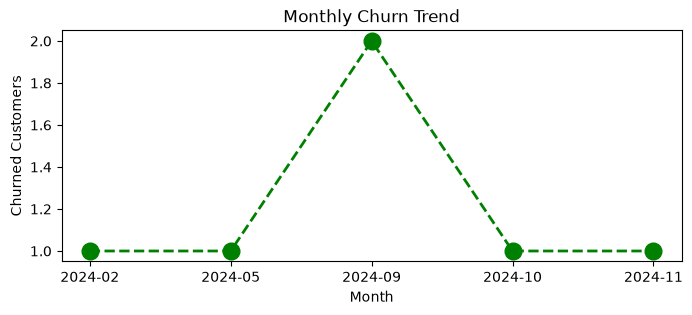

In [69]:
# 4.1 Monthly Churn Trend (Time Series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values,  color='green', marker='o', linestyle='dashed',  linewidth=2, markersize=12)
plt.title('Monthly Churn Trend')
plt.xlabel('Month')  
plt.ylabel('Churned Customers')
plt.show()

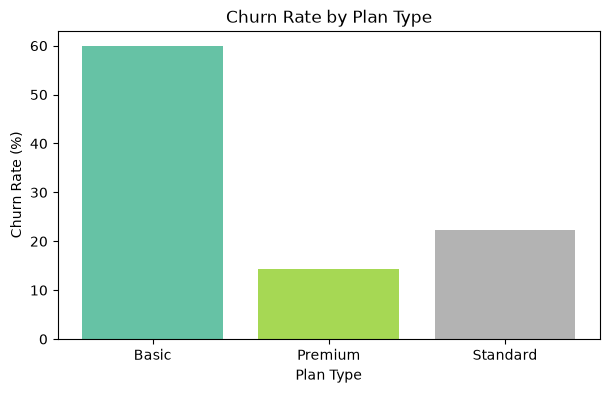

In [70]:
# 4.2 Churn Rate by Plan type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()*100

# colors = ['yellow', 'purple', 'blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(7,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title('Churn Rate by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')
plt.show()

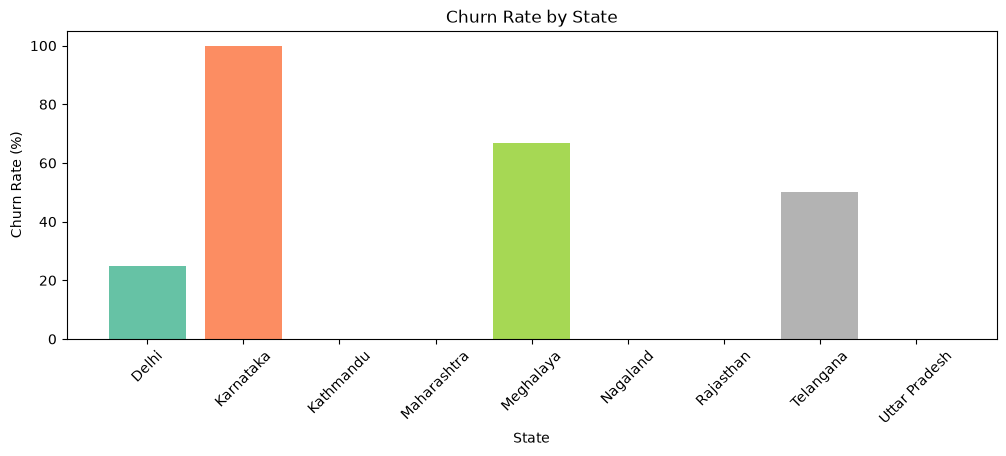

In [71]:
# 4.3 Churn by States
churn_plan = df_visual.groupby('state')['churn_flag'].mean()*100

# colors = ['yellow', 'purple', 'blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(12,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title('Churn Rate by State')
plt.xlabel('State')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()

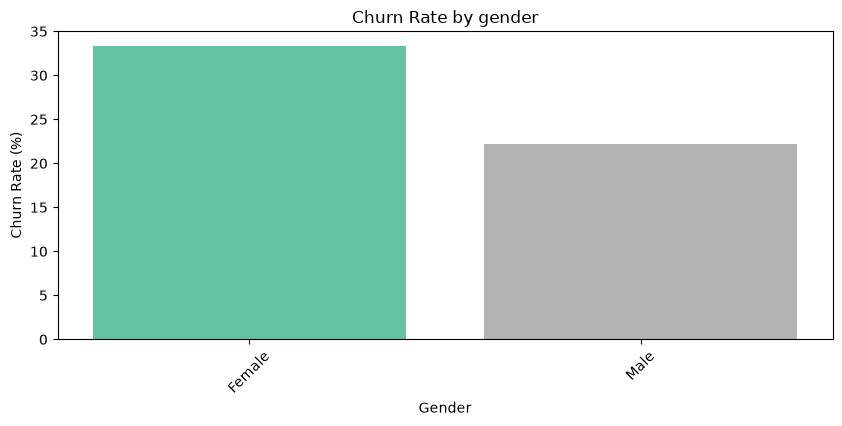

In [72]:
# 4.3 Churn by Gender
churn_plan = df_visual.groupby('gender')['churn_flag'].mean()*100

# colors = ['yellow', 'purple', 'blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(10,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title('Churn Rate by gender')
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()

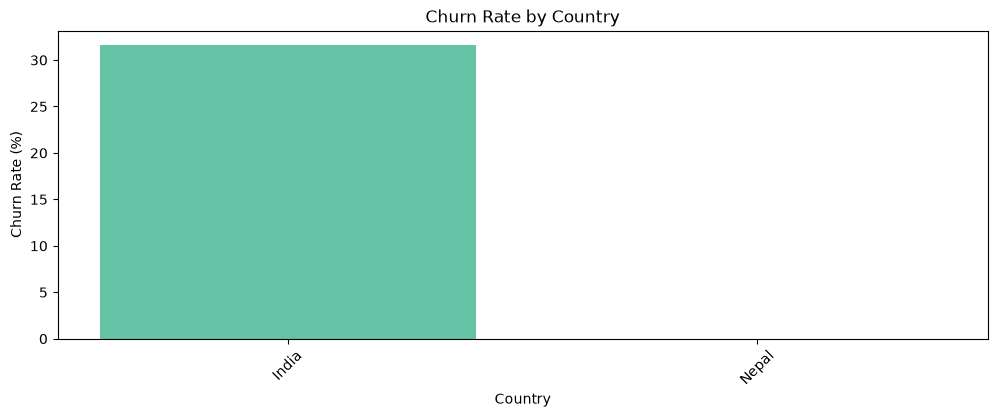

In [73]:
# 4.3 Churn by Country
churn_plan = df_visual.groupby('country')['churn_flag'].mean()*100

# colors = ['yellow', 'purple', 'blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(12,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title('Churn Rate by Country')
plt.xlabel('Country')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()

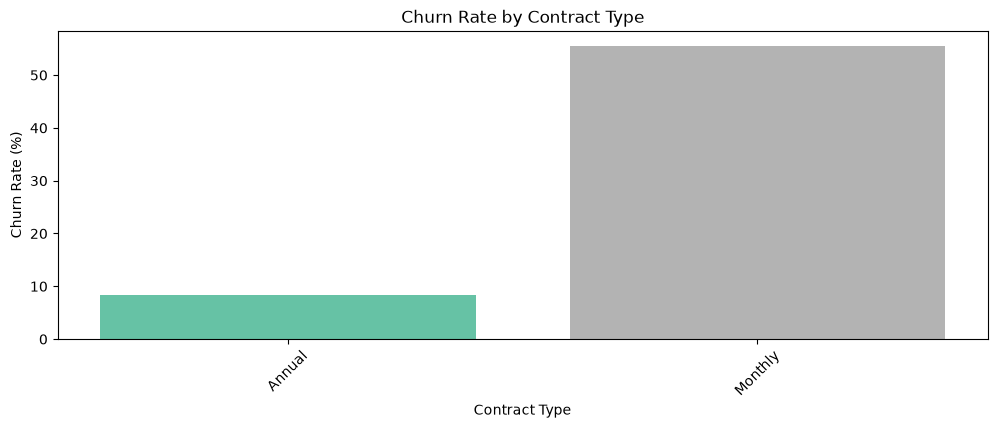

In [74]:
# 4.3 Churn by contract_type
churn_plan = df_visual.groupby('contract_type')['churn_flag'].mean()*100

# colors = ['yellow', 'purple', 'blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(12,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.show()

## Visulaization using Seaborn

In [75]:
# Heatmap (Correlation Matrix)

In [76]:
# encoding - convert str to numeric so that we can find corr between features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count', 'age',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

In [77]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [94]:
# remove warnings
import warnings
warnings.filterwarnings("ignore")

In [96]:
# incorrect method of encoding - as numbers are not assigned based on priority
df_encoded = df_visual[['plan_type', 'subscription_type', 'contract_type', 'gender', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

categorial_cols = ['plan_type', 'subscription_type', 'contract_type','gender','churn_risk']

for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

<Axes: >

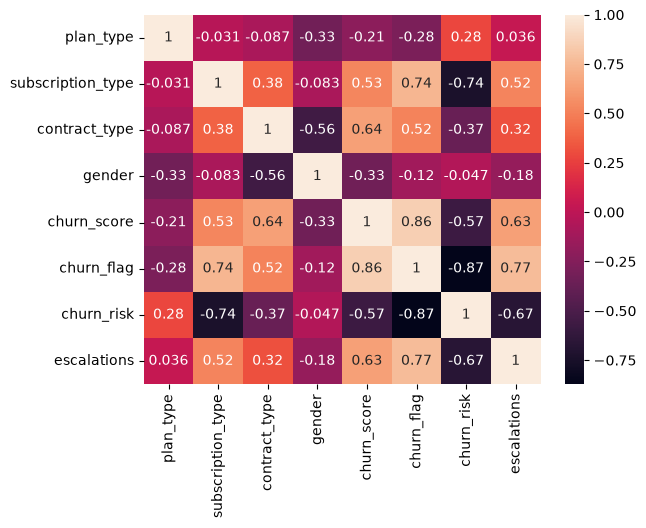

In [ ]:
# Heatmap (correlation matrix) 

sns.heatmap(df_encoded.corr(), annot=True)

In [99]:
print('plan_type :', df_visual['plan_type'].unique())
print('subscription_type :', df_visual['subscription_type'].unique())
print('contract_type :', df_visual['contract_type'].unique())
print('Gender :', df_visual['gender'].unique())
print('churn_risk :', df_visual['churn_risk'].unique())

plan_type : <StringArray>
['Standard', 'Premium', 'Basic']
Length: 3, dtype: str
subscription_type : <StringArray>
['Refferal', 'Paid', 'Organic']
Length: 3, dtype: str
contract_type : <StringArray>
['Annual', 'Monthly']
Length: 2, dtype: str
Gender : <StringArray>
['Male', 'Female']
Length: 2, dtype: str
churn_risk : <StringArray>
['low', 'high', 'med']
Length: 3, dtype: str


In [101]:
# Correct method of encoding - based on priority
df_encoded = df_visual[['plan_type', 'subscription_type', 'contract_type', 'gender', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

categorial_cols = ['plan_type', 'subscription_type', 'contract_type','gender','churn_risk']

order_mappings = {
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'subscription_type' : ['Refferal', 'Paid', 'Organic'],
    'contract_type' : ['Monthly', 'Annual'],
    'gender' : ['Male', 'Female'],
    'churn_risk': ['low', 'med', 'high']
    }

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

In [102]:
df_visual[['plan_type', 'subscription_type', 'contract_type', 'gender', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,subscription_type,contract_type,gender,churn_score,churn_flag,churn_risk,escalations
0,Standard,Refferal,Annual,Male,12,0,low,0
1,Premium,Paid,Annual,Male,91,1,high,1
2,Basic,Organic,Monthly,Female,34,0,low,0
3,Premium,Paid,Annual,Male,8,0,low,0
4,Standard,Refferal,Monthly,Female,88,1,high,1


In [103]:
df_encoded.head()

,plan_type,subscription_type,contract_type,gender,churn_score,churn_flag,churn_risk,escalations
0,1,0,1,0,12,0,0,0
1,2,1,1,0,91,1,2,1
2,0,2,0,1,34,0,0,0
3,2,1,1,0,8,0,0,0
4,1,0,0,1,88,1,2,1


<Axes: >

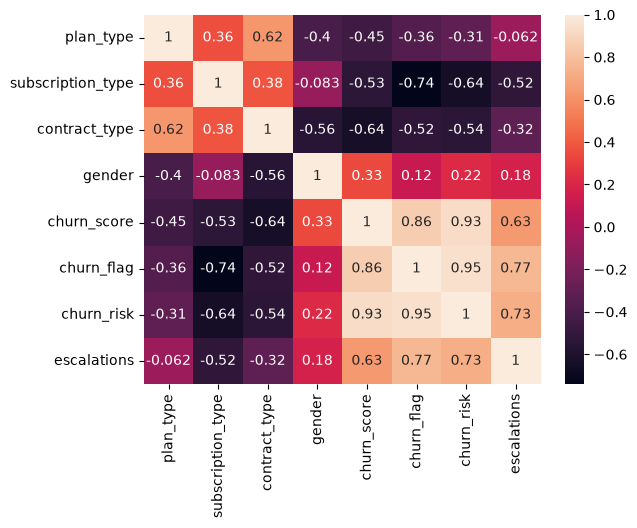

In [104]:
# Heatmap (correlation matrix)
sns.heatmap(df_encoded.corr(), annot=True)

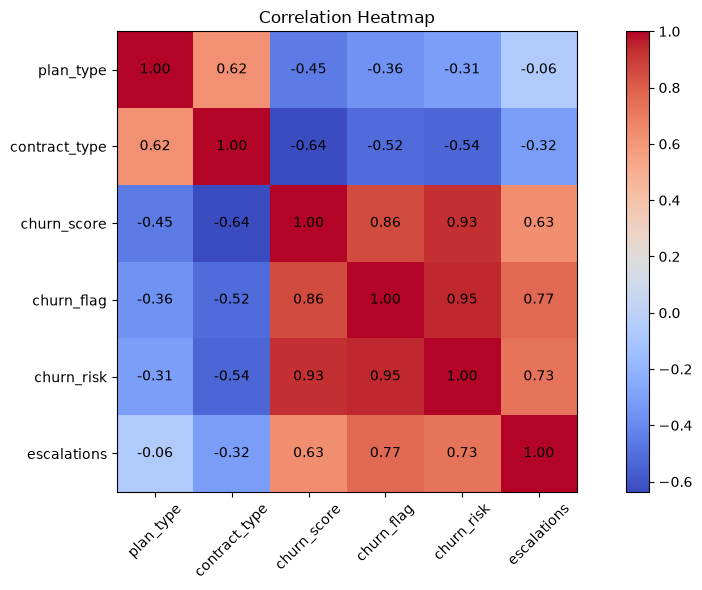

In [86]:
# Heatmap Using Matplotlib - difficult to plot it

corr_matrix = df_encoded.corr() # Correlation matrix

fig, ax = plt.subplots(figsize=(10, 6)) # Create figure

cax = ax.imshow(corr_matrix, cmap='coolwarm') # Heatmap

fig.colorbar(cax) # Add colorbar

# Axis labels
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.columns)))

ax.set_xticklabels(corr_matrix.columns, rotation=45)
ax.set_yticklabels(corr_matrix.columns)

# Annotate values inside cells
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha='center',
            va='center'
        )

plt.title('Correlation Heatmap') # Title

plt.tight_layout()
plt.show()

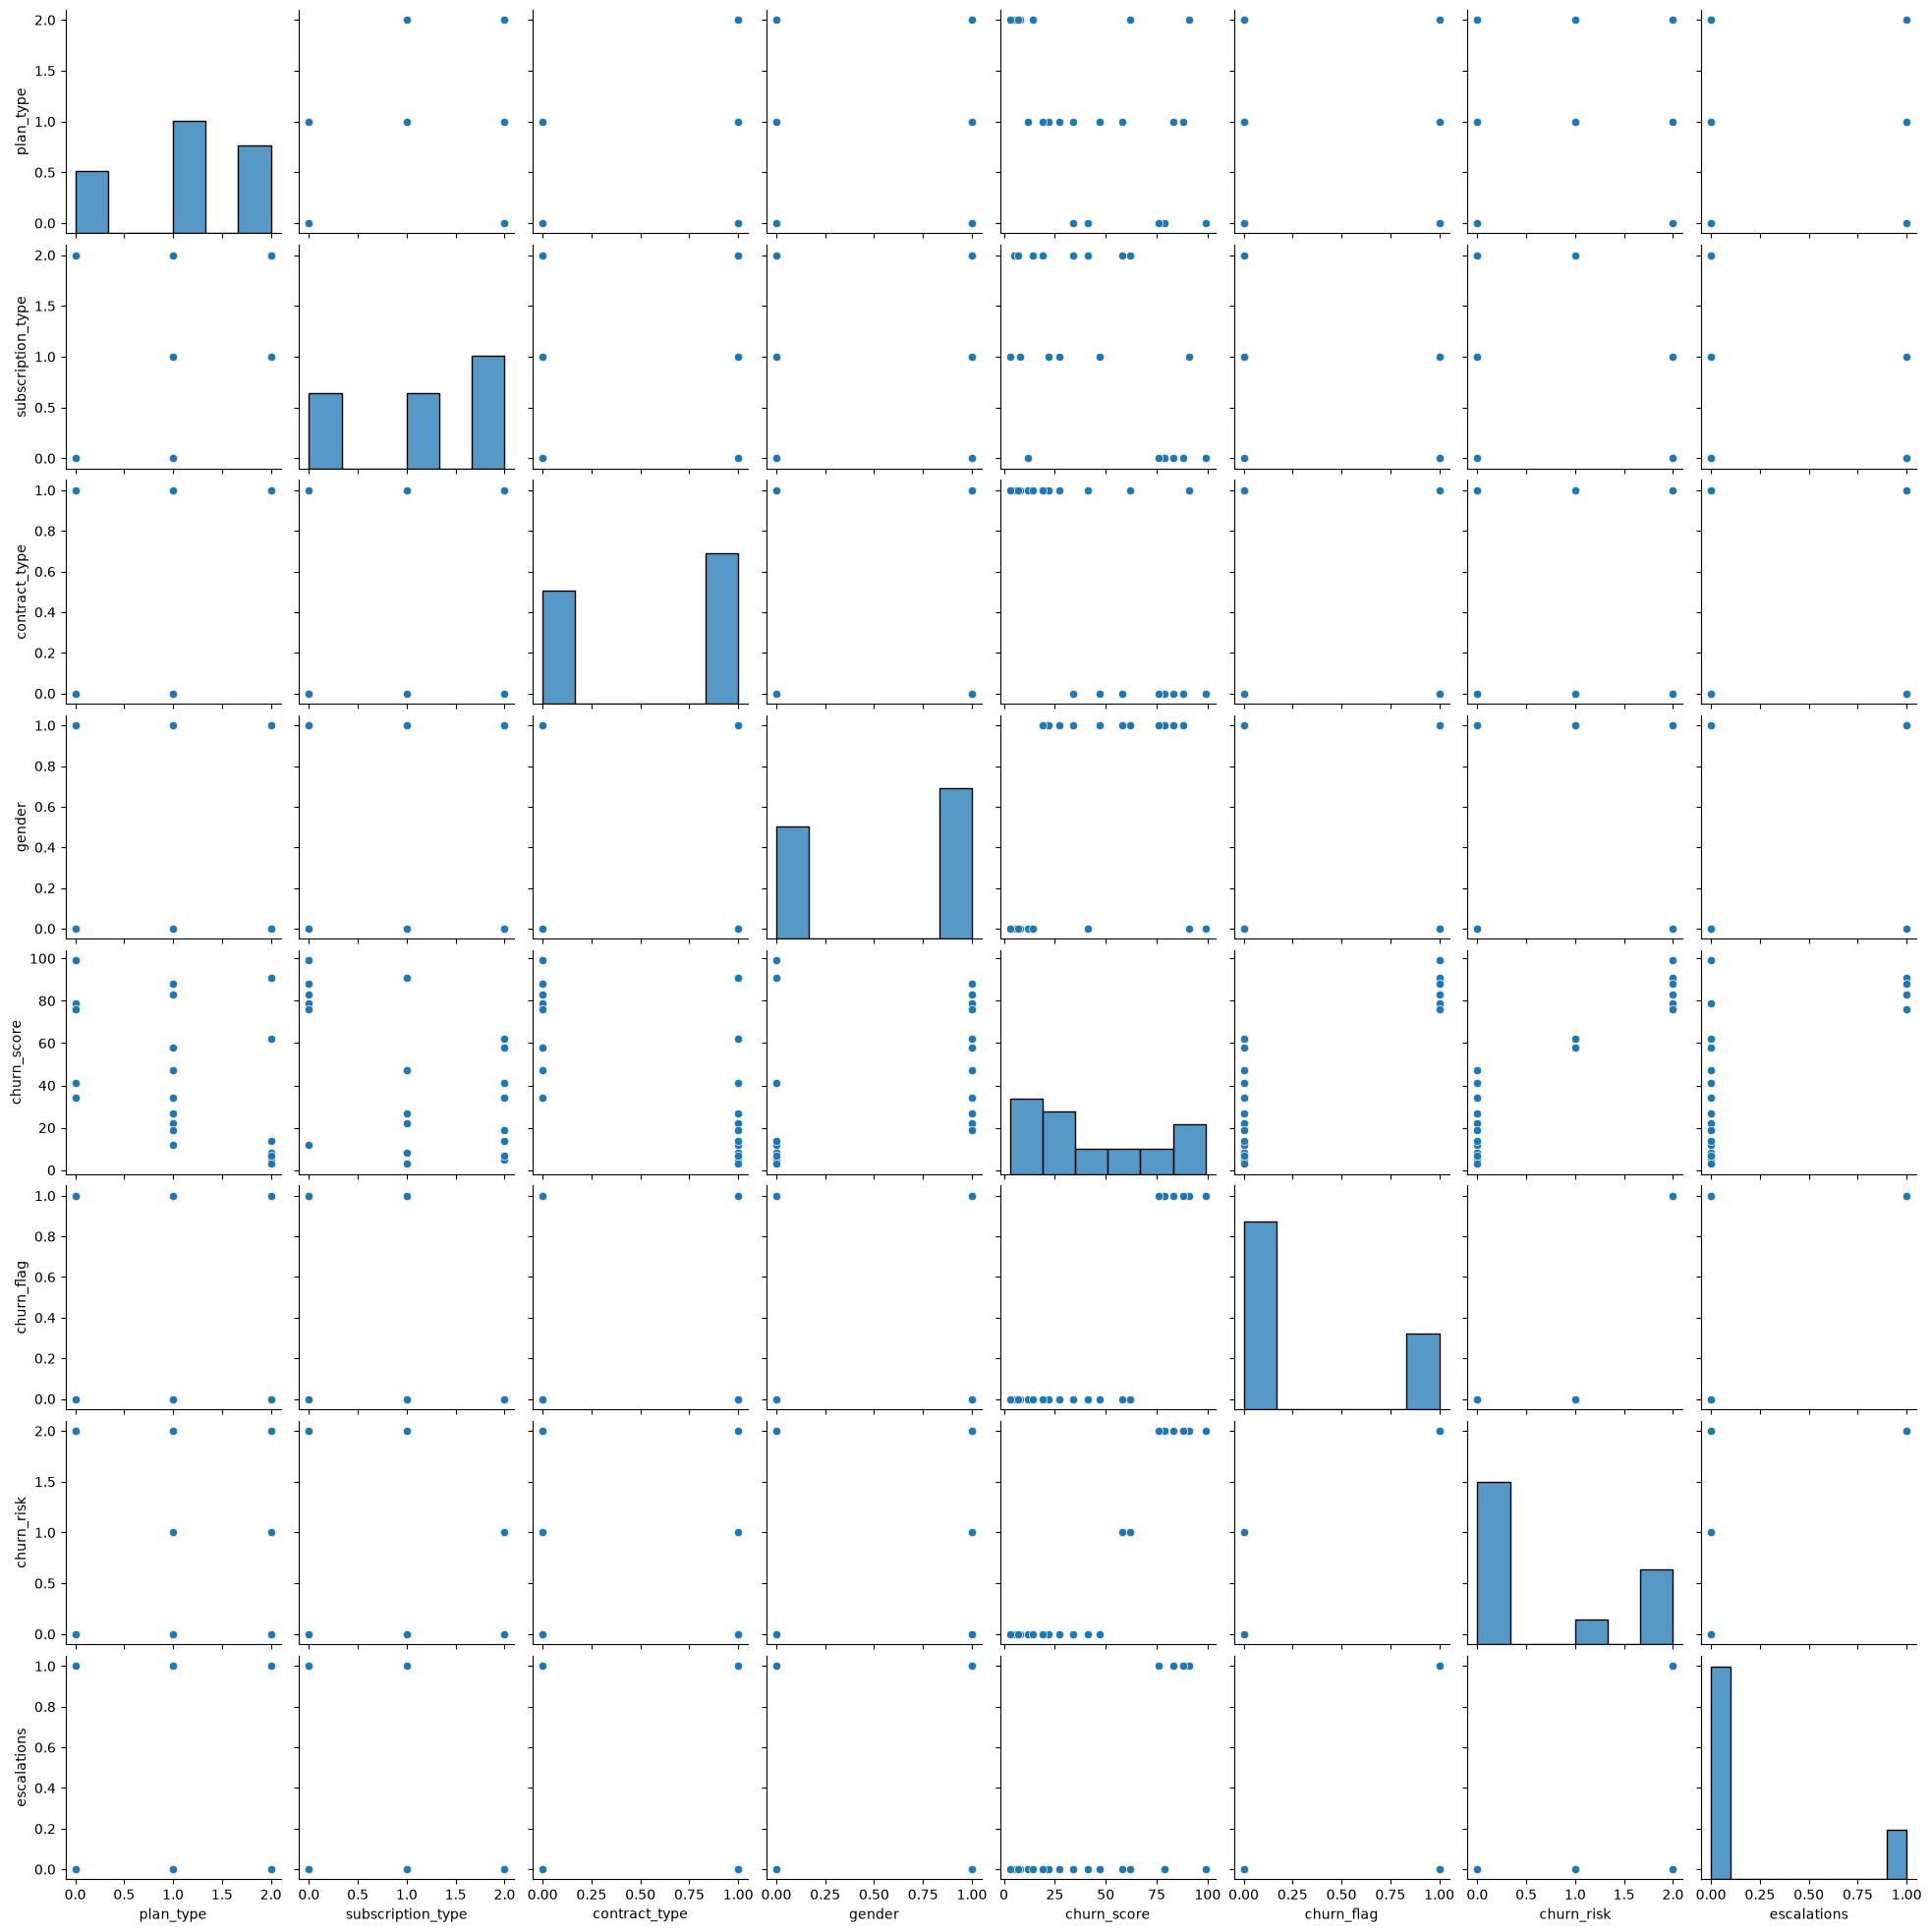

In [105]:
# pairplot - Plot pairwise relationships in a dataset
sns.pairplot(df_encoded)

In [88]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count', 'age',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

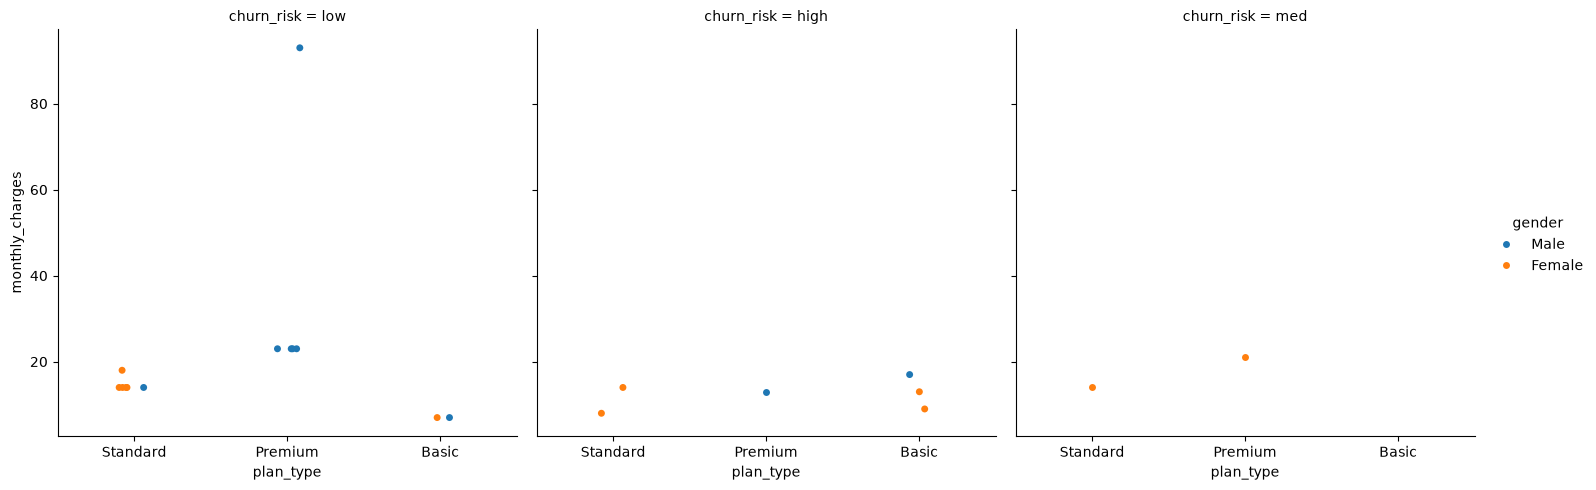

In [ ]:
# catplt/Facegrid plot - multi-dim comparison

sns.catplot(
    data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk')

## Pivot table

In [110]:
# Pivot Table

pd.pivot_table(
    df_visual,
    index='plan_type',
    values='churn_flag',
    aggfunc = 'mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [111]:
# pivot table using multiple cols and agg type

pd.pivot_table(
    df_visual,
    index ='plan_type',
    values=['monthly_charges', 'customerid', 'churn_flag'],
    aggfunc = {
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn_flag' : 'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


## Project Completed :)

In [92]:
# Project Completed Here. All the best! :)

## Working with SQL in Python

In [107]:
import sqlite3

In [112]:
# create db in sql
conn = sqlite3.connect('test_database.sqlite')

#table details
conn.execute("CREATE TABLE users (first_name TEXT, country TEXT, budget INTEGER)")

# commit and save
conn.commit()

print("Cretaed Table successfully!")

Cretaed Table successfully!


In [113]:
# insert data

cursor = conn.cursor()

# write sql query to insert records in sql table
cursor.execute(
    """
        INSERT INTO users VALUES
            ('Madhav', 'India', 5000),
            ('Rishabh', 'Germany', 2500),
            ('Vishakha', 'India', 3500)
    """
)

# commit and save
conn.commit()

print("Data Inserted successfully!")

Data Inserted successfully!


In [114]:
# check inserted data in table
conn = sqlite3.connect('test_database.sqlite')

query = """SELECT * FROM users"""

df_results = pd.read_sql(query, conn)

df_results.head()

,first_name,country,budget
0,Madhav,India,5000
1,Rishabh,Germany,2500
2,Vishakha,India,3500


In [115]:
# aggregation
query = """
        SELECT country, SUM(budget) as total_budget
        FROM users
        GROUP BY country
"""
df_agg = pd.read_sql(query, conn)
df_agg

,country,total_budget
0,Germany,2500
1,India,8500


In [116]:
# always close the conn with db once the task is over
conn.close()